In [57]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [58]:
# load dataset

df = pd.read_excel("hiring_dataset_10000 cleaned  data.xlsx")

df.head()

,Candidate_ID,Job_Role,Application_Date,Screening_Date,Interview_Date,Offer_Date,Joining_Date,Source,Recruiter_ID,Status
0,1,Project Manager,2023-03-10,2023-03-15,2023-03-17,2023-03-20,2023-03-26,Company Website,R4,Selected
1,2,Data Analyst,2023-04-18,2023-04-19,2023-04-24,2023-04-25,2023-05-06,Company Website,R3,Selected
2,3,Business Analyst,2023-04-28,2023-05-03,2023-05-05,2023-05-08,2023-05-13,LinkedIn,R4,Selected
3,4,Project Manager,2023-12-18,2023-12-20,2023-12-25,2023-12-26,2024-01-08,Company Website,R2,Selected
4,5,Project Manager,2023-06-26,NaT,NaT,NaT,NaT,LinkedIn,R2,Rejected


In [59]:
#data understanding
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())







Shape: (10000, 10)

Missing Values:
 Candidate_ID           0
Job_Role               0
Application_Date       0
Screening_Date       989
Interview_Date      2024
Offer_Date          2949
Joining_Date        2949
Source                 0
Recruiter_ID           0
Status                 0
dtype: int64


In [60]:
# convert date columns
df['Application_Date'] = pd.to_datetime(df['Application_Date'])
df['Screening_Date'] = pd.to_datetime(df['Screening_Date'])
df['Interview_Date'] = pd.to_datetime(df['Interview_Date'])
df['Offer_Date'] = pd.to_datetime(df['Offer_Date'])
df['Joining_Date'] = pd.to_datetime(df['Joining_Date'])

In [61]:
# hiring funnel kpi's
total = len(df)
screened = df['Screening_Date'].notna().sum()
interviewed = df['Interview_Date'].notna().sum()
offered = df['Offer_Date'].notna().sum()
joined = df['Joining_Date'].notna().sum()

print("Total Applications:", total)
print("Screened:", screened)
print("Interviewed:", interviewed)
print("Offered:", offered)
print("Joined:", joined)

print("\nConversion Rates:")
print("Screening Rate:", round(screened/total,2))
print("Interview Rate:", round(interviewed/total,2))
print("Offer Rate:", round(offered/total,2))
print("Joining Rate:", round(joined/total,2))

Total Applications: 10000
Screened: 9011
Interviewed: 7976
Offered: 7051
Joined: 7051

Conversion Rates:
Screening Rate: 0.9
Interview Rate: 0.8
Offer Rate: 0.71
Joining Rate: 0.71


In [62]:
#Filter Selected Candidates
selected_df = df[df['Status'] == 'Selected'].copy()

print("Selected Candidates:", selected_df.shape)

Selected Candidates: (7051, 10)


In [63]:
#Create Time Columns
selected_df['Time_to_Screen'] = (selected_df['Screening_Date'] - selected_df['Application_Date']).dt.days
selected_df['Time_to_Interview'] = (selected_df['Interview_Date'] - selected_df['Screening_Date']).dt.days
selected_df['Time_to_Offer'] = (selected_df['Offer_Date'] - selected_df['Interview_Date']).dt.days
selected_df['Time_to_Join'] = (selected_df['Joining_Date'] - selected_df['Offer_Date']).dt.days

selected_df['Total_Hiring_Time'] = (selected_df['Joining_Date'] - selected_df['Application_Date']).dt.days

In [64]:
# kpi analysis
print("Average Hiring Time:", selected_df['Total_Hiring_Time'].mean())

stage_avg = selected_df[['Time_to_Screen','Time_to_Interview','Time_to_Offer','Time_to_Join']].mean()

print("\nStage-wise Time:\n", stage_avg)

Average Hiring Time: 19.973904410721882

Stage-wise Time:
 Time_to_Screen       3.012055
Time_to_Interview    4.480499
Time_to_Offer        2.507871
Time_to_Join         9.973479
dtype: float64


In [65]:
#bottleneck
print("Bottleneck Stage:", stage_avg.idxmax())

Bottleneck Stage: Time_to_Join


In [66]:
#source analysis
print(selected_df.groupby('Source')['Total_Hiring_Time'].mean())

Source
Company Website    19.848065
Job Portal         20.289397
LinkedIn           19.898551
Referral           19.871908
Name: Total_Hiring_Time, dtype: float64


In [67]:
#recruiter performance

print(selected_df.groupby('Recruiter_ID')['Total_Hiring_Time'].mean().nsmallest(5))

Recruiter_ID
R3    19.897101
R1    19.942510
R4    19.962880
R2    20.097947
Name: Total_Hiring_Time, dtype: float64


In [68]:
#visualization

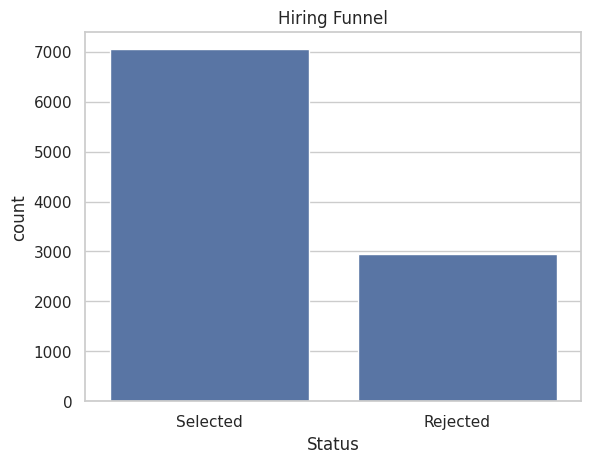

In [69]:
#Hiring Funnel

sns.countplot(x='Status', data=df)
plt.title("Hiring Funnel")
plt.show()

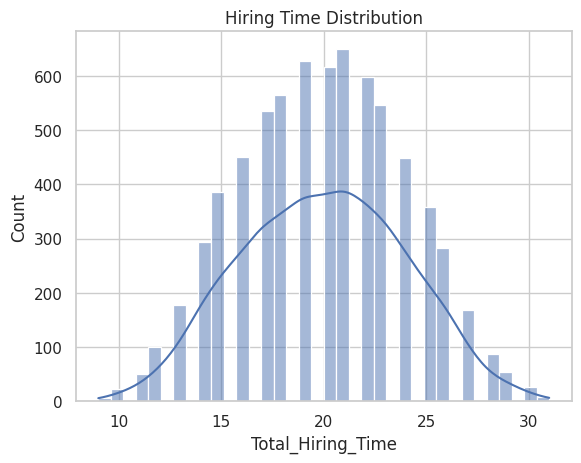

In [70]:
#Distribution
sns.histplot(selected_df['Total_Hiring_Time'], kde=True)
plt.title("Hiring Time Distribution")
plt.show()

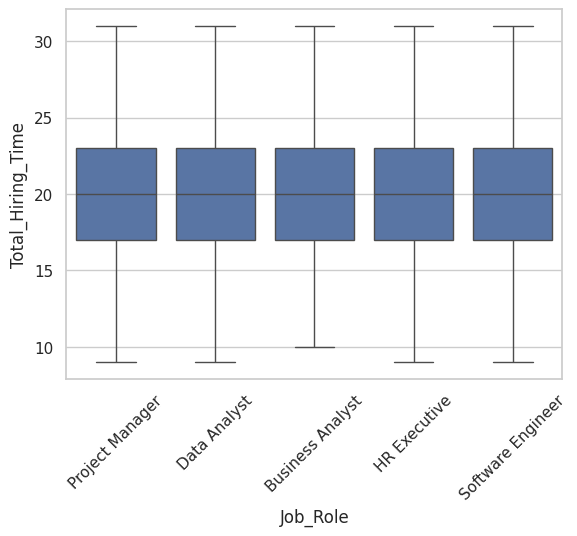

In [71]:
#job role
sns.boxplot(x='Job_Role', y='Total_Hiring_Time', data=selected_df)
plt.xticks(rotation=45)
plt.show()

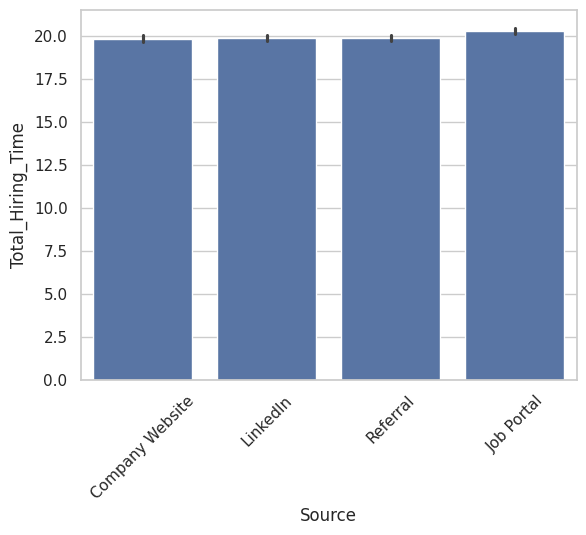

In [72]:
#Source
sns.barplot(x='Source', y='Total_Hiring_Time', data=selected_df)
plt.xticks(rotation=45)
plt.show()

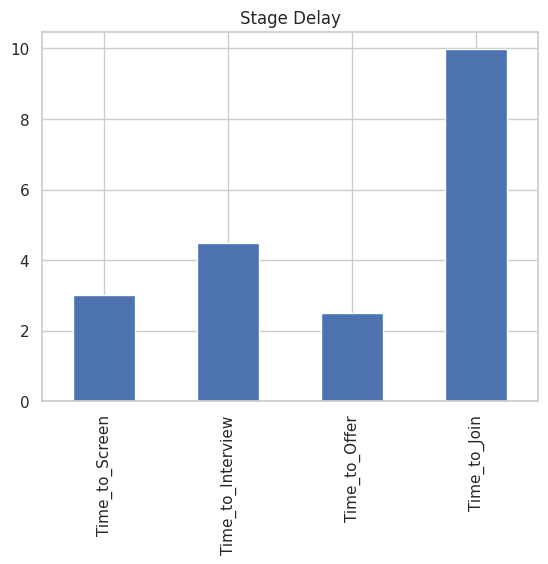

In [73]:
#Stage Comparison
stage_avg.plot(kind='bar')
plt.title("Stage Delay")
plt.show()

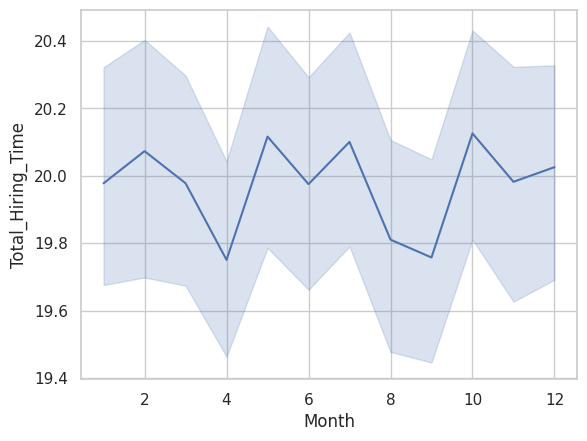

In [74]:
#trend over month
selected_df['Month'] = selected_df['Application_Date'].dt.month

sns.lineplot(x='Month', y='Total_Hiring_Time', data=selected_df)
plt.show()

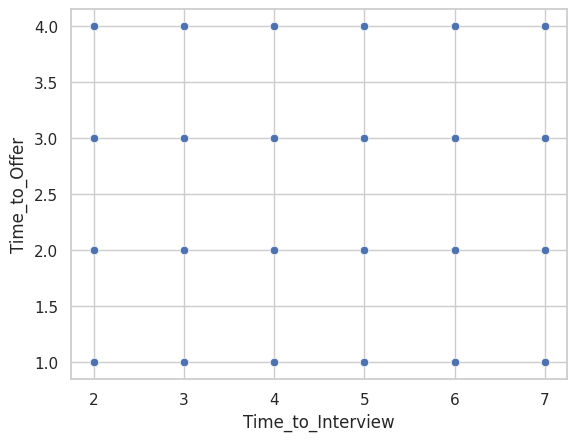

In [75]:
#scatterplot
sns.scatterplot(x='Time_to_Interview', y='Time_to_Offer', data=selected_df)
plt.show()

In [76]:
#import ml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [77]:
#prepare data
ml_df = selected_df.dropna()

X = ml_df[['Time_to_Screen','Time_to_Interview','Time_to_Offer','Time_to_Join']]
y = ml_df['Total_Hiring_Time']

In [78]:
#split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [79]:
#train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [80]:
#predict
y_pred = model.predict(X_test)

In [81]:
#evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.7469954809151996e-15
R2 Score: 1.0


In [82]:

#FINAL INSIGHT
print("Average Hiring Time:", selected_df['Total_Hiring_Time'].mean())
print("Main Delay Stage:", stage_avg.idxmax())

Average Hiring Time: 19.973904410721882
Main Delay Stage: Time_to_Join
